<a href="https://colab.research.google.com/github/rw61475-cloud/implementasi-menggunakan-c45-phyton/blob/main/decisiontree_2433027_RiniWidiastuti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Langkah 1 yaitu input dataset ke Google Colabs

Langkah 2 : Import Library
1. Pandas, digunakan untuk membaca dataset
2. matplotlib, digunakan untuk menampilkan gambar pohon keputusan
3. DecisionTreeClassifier, digunakan untuk membuat model C4.5/Decision Tree
4. tree, digunakan untuk menggambar pohon keputusan
5. LabelEncoder, digunakan untuk mengubah teks menjadi angka.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.preprocessing import LabelEncoder

Langkah 3 : pd.read.csv digunakan untuk membaca Dataset berkestensi CSV. outputnya akan menampilkan data dari dataset yang kita inputkan tadi.

In [6]:
dataset = pd.read_csv('Dataset_Rekomendasi_Peserta.csv')

dataset

,No,Kehadiran,Lingkungan,Kerjasama,Prakarsa,Rekomendasi
0,1,Rajin,Kurang Peduli,Mampu,Tidak Inisiatif,Tidak
1,2,Cukup,Peduli,Tidak Mampu,Inisiatif,Ya
2,3,Rajin,Kurang Peduli,Tidak Mampu,Kurang Inisiatif,Tidak
3,4,Rajin,Peduli,Mampu,Inisiatif,Ya
4,5,Rajin,Peduli,Mampu,Inisiatif,Ya
5,6,Cukup,Peduli,Tidak Mampu,Inisiatif,Ya
6,7,Kurang,Peduli,Tidak Mampu,Kurang Inisiatif,Tidak
7,8,Rajin,Peduli,Tidak Mampu,Kurang Inisiatif,Ya
8,9,Rajin,Peduli,Mampu,Inisiatif,Ya
9,10,Kurang,Kurang Peduli,Tidak Mampu,Kurang Inisiatif,Tidak


Langkah 4 : Encoding mengubah huruf menjadi teks.
1. LabelEncoder, digunakan untuk mengubah teks menjadi angka agar bisa diproses oleh algoritma Decision Tree.
2. Sistem LabelEncoder mengubah data kategorikal menjadi angka berdasarkan urutan alfabet. Angka yang dihasilkan hanya berfungsi sebagai kode pengganti teks agar dapat diproses oleh algoritma Decision Tree.
3. Nilai yang lebih besar tidak menunjukkan bahwa suatu kategori lebih baik, lebih penting, atau memiliki tingkat yang lebih tinggi dibandingkan kategori lainnya.


In [9]:
le = LabelEncoder()

dataset['Kehadiran'] = le.fit_transform(dataset['Kehadiran'])
dataset['Lingkungan'] = le.fit_transform(dataset['Lingkungan'])
dataset['Kerjasama'] = le.fit_transform(dataset['Kerjasama'])
dataset['Prakarsa '] = le.fit_transform(dataset['Prakarsa '])
dataset['Rekomendasi'] = le.fit_transform(dataset['Rekomendasi'])

dataset

,No,Kehadiran,Lingkungan,Kerjasama,Prakarsa,Rekomendasi
0,1,2,0,0,2,0
1,2,0,1,1,0,1
2,3,2,0,1,1,0
3,4,2,1,0,0,1
4,5,2,1,0,0,1
5,6,0,1,1,0,1
6,7,1,1,1,1,0
7,8,2,1,1,1,1
8,9,2,1,0,0,1
9,10,1,0,1,1,0


Langkah 5 : Menentukan kolom x dan y.
1. atribut (x) terdiri dari kolom kehadiran, lingkungan, kerjasama, dan prakarsa.
2. sedangkan kelas (y) hanya terdiri dari kolom rekomendasi.

In [10]:
X = dataset[['Kehadiran',
             'Lingkungan',
             'Kerjasama',
             'Prakarsa ']]

y = dataset['Rekomendasi']

Langkah 6 : Membuat Model
1. criterion='entropy', digunakan karena algoritma C4.5 menentukan node berdasarkan nilai Entropy dan Information Gain.
2. dengan menggunakan parameter tersebut, model Decision Tree akan memilih atribut yang memiliki Gain tertinggi sebagai node, sesuai dengan perhitungan manual yang telah dilakukan sebelumnya.

In [11]:
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=0
)

Langkah 7 : Training
Python mulai menghitung entropy, gain, dan membentuk decision tree secara otomatis.

In [12]:
model.fit(X, y)

DecisionTreeClassifier(criterion='entropy', random_state=0)

Langkah 8 : Menampilkan Pohon Keputusan
1. plt.figure(figsize=(12,8)), digunakan untuk membuat kanvas atau area gambar untuk menampilkan Decision Tree.
2. figsize=(12,8), artinya lebar = 12 dan tinggi = 8 yaitu Semakin besar ukurannya, semakin mudah pohon keputusan dibaca.
3. model, digunakan untuk menghitung Entrophy, Gain, Root Node, dan Cabang-cabang Decision Tree.
4. parameter feature_names digunakan untuk menampilkan nama atribut
5. class_names digunakan untuk menampilkan label kelas hasil klasifikasi
6. filled=True digunakan untuk memberikan warna pada setiap node agar lebih mudah dibaca.
7. plt.show(), menampilkan gambar Decision Tree yang telah dibuat.
8. Kode plot_tree() digunakan untuk memvisualisasikan pohon keputusan yang telah dibentuk oleh algoritma Decision Tree.

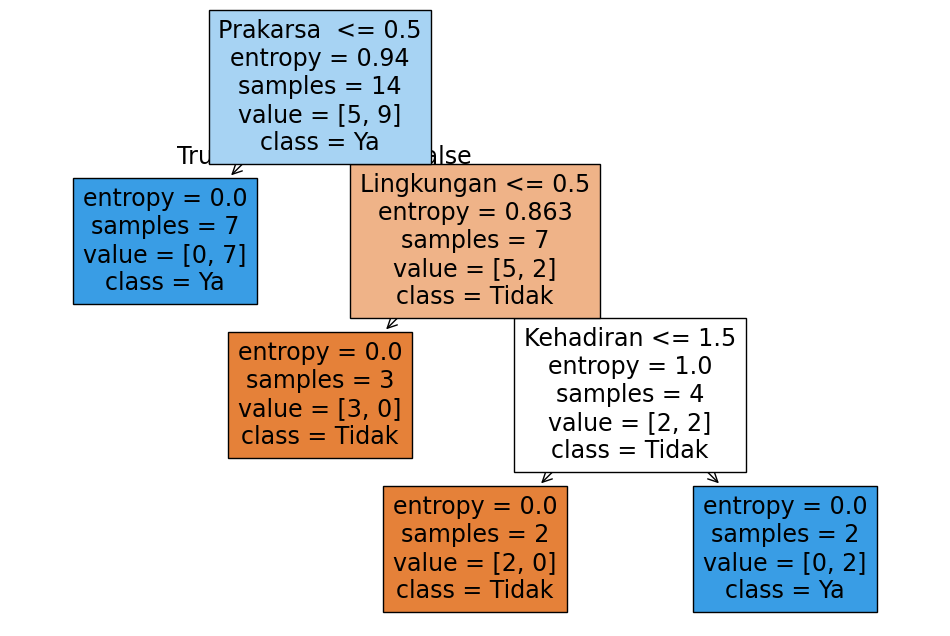

In [13]:
plt.figure(figsize=(12,8))

tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Tidak','Ya'],
    filled=True
)

plt.show()

Langkah 9 : Prediksi Data Baru
Karena data tadi sudah di-encode, kita perlu tahu dulu hasil encoding masing-masing kategori

In [14]:
print(dataset)

    No  Kehadiran  Lingkungan  Kerjasama  Prakarsa   Rekomendasi
0    1          2           0          0          2            0
1    2          0           1          1          0            1
2    3          2           0          1          1            0
3    4          2           1          0          0            1
4    5          2           1          0          0            1
5    6          0           1          1          0            1
6    7          1           1          1          1            0
7    8          2           1          1          1            1
8    9          2           1          0          0            1
9   10          1           0          1          1            0
10  11          0           1          0          1            0
11  12          2           1          0          2            1
12  13          0           1          0          0            1
13  14          2           1          0          0            1


Langkah Prediksi,
Tahap prediksi dilakukan dengan memasukkan data peserta baru yang telah dikonversi ke dalam bentuk numerik menggunakan Label Encoding.
1. menentukan nilai atribut Kehadiran yang akan diuji, nilai 2 merupakan hasil encoding dari kategori Rajin.
2. menentukan nilai atribut Lingkungan yang akan diuji, ilai 1 merupakan hasil encoding dari kategori Peduli.
3. menentukan nilai atribut Kerjasama yang akan diuji, nilai 0 merupakan hasil encoding dari kategori Mampu.
4. menentukan nilai atribut Prakarsa yang akan diuji, nilai 0 merupakan hasil encoding dari kategori Inisiatif.
5. Hasil prediksi yang diperoleh adalah [1], yang menunjukkan bahwa peserta tersebut termasuk dalam kategori direkomendasikan (Ya).

In [16]:
nilai_kehadiran = 2      # Rajin
nilai_lingkungan = 1     # Peduli
nilai_kerjasama = 0      # Mampu
nilai_prakarsa = 0       # Inisiatif

hasil = model.predict([[nilai_kehadiran,
                        nilai_lingkungan,
                        nilai_kerjasama,
                        nilai_prakarsa]])

print(hasil)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Langkah 10 : Menghitung Akurasi
setelah tahap prediksi terdapat tahap evaluasi
1. accuracy_score(), berfungsi untuk menghitung tingkat akurasi model klasifikasi seberapa banyak akurasi data yang diprediksi secara benar oleh model dibandingkan seluruh data yang diuji.
2. model.predict(X), digunakan untuk melakukan prediksi terhadap seluruh data atribut (X) menggunakan model Decision Tree yang telah dilatih sebelumnya.
3. accuracy_score(y, prediksi), digunakan untuk menghitung akurasi. yaitu membandingkan y merupakan data asli sedangkan prediksi merupakan hasil prediksi model.
5. Akurasi =
(Jumlah Prediksi Benar / Jumlah Seluruh Data) × 100%
6. print("Akurasi :", akurasi), digunakan untuk menampilkan nilai akurasi model ke layar.
7. akurasi dapat 100% (1.0) karena model diuji menggunakan data yang sama dengan data pelatihan (X dan y yang sama).

In [17]:
from sklearn.metrics import accuracy_score

prediksi = model.predict(X)

akurasi = accuracy_score(y, prediksi)

print("Akurasi :", akurasi)

Akurasi : 1.0


In [18]:
from sklearn.metrics import accuracy_score

prediksi = model.predict(X)

benar = sum(y == prediksi)
salah = len(y) - benar
akurasi = accuracy_score(y, prediksi)

print("Label sebenarnya :", list(y))
print("Hasil prediksi   :", list(prediksi))
print("Prediksi benar   :", benar, "data")
print("Prediksi salah   :", salah, "data")
print("Akurasi          :", round(akurasi*100,2), "%")

Label sebenarnya : [0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1]
Hasil prediksi   : [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1)]
Prediksi benar   : 14 data
Prediksi salah   : 0 data
Akurasi          : 100.0 %


Kesimpulan
1. Terdapat sedikit perbedaan struktur pohon antara perhitungan manual dan implementasi Python. Hal ini disebabkan algoritma Decision Tree pada Scikit-Learn melakukan pemilihan split secara otomatis berdasarkan nilai entropy sehingga menghasilkan struktur pohon yang lebih sederhana. Namun root node dan hasil klasifikasi tetap konsisten dengan perhitungan manual.
2. Perhitungan manual menghasilkan pohon keputusan berdasarkan proses gain yang dihitung tahap demi tahap. Sedangkan Python membentuk pohon secara otomatis menggunakan entropy sehingga struktur cabang sedikit berbeda, namun root node tetap Prakarsa dan hasil klasifikasinya tetap sama.